# Model Training & Evaluation

This notebook covers:
1. Data Loading & Splitting
2. Baseline Model
3. Multiple Model Training
4. Model Evaluation & Comparison
5. Feature Importance Analysis
6. Model Selection & Saving

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, 
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 2. Load Data

In [3]:
# Load the engineered features dataset
data_path = Path('../data/processed/v0.1.1/features_engineered_dataset.csv')

df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

# Prepare features and target
X = df.drop('label', axis=1)
y = df['label']

print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Attack rate: {y.mean()*100:.2f}%")

Dataset shape: (6412, 21)

First few rows:
   path_depth  path_encoded_chars  query_param_count  query_special_chars  \
0    0.936430           -0.137914           1.167814            -0.161005   
1    0.936430           -0.137914           1.167814            -0.161005   
2   -1.862036           -0.137914          -0.354761            -0.161005   
3   -1.862036           -0.137914          -0.354761            -0.161005   
4   -1.862036           -0.137914          -0.354761            -0.161005   

   suspicious_path  header_count  user_agent_length  body_contains_code  \
0         0.476926     -1.605782          -1.007707           -0.186264   
1         0.476926     -1.605782          -1.007707           -0.186264   
2        -1.447586     -0.321777          -1.007707           -0.186264   
3        -1.447586     -0.321777          -1.007707           -0.186264   
4        -1.447586     -0.321777          -1.007707           -0.186264   

   body_special_chars_ratio  ip_attack_rate

## 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training attack rate: {y_train.mean()*100:.2f}%")
print(f"Test attack rate: {y_test.mean()*100:.2f}%")

Training set: 5129 samples
Test set: 1283 samples
Training attack rate: 48.74%
Test attack rate: 48.71%


## 4. Train Multiple Models

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}
trained_models = {}

print("Training models...\n")

for model_name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'time': time.time() - start
    }
    
    print(f"{model_name:20s} - Acc: {results[model_name]['accuracy']:.4f}, F1: {results[model_name]['f1']:.4f}, AUC: {results[model_name]['roc_auc']:.4f}")

Training models...

Logistic Regression  - Acc: 0.9080, F1: 0.9114, AUC: 0.9697
Random Forest        - Acc: 0.9564, F1: 0.9539, AUC: 0.9912
Gradient Boosting    - Acc: 0.9532, F1: 0.9502, AUC: 0.9913
XGBoost              - Acc: 0.9602, F1: 0.9580, AUC: 0.9917
SVM                  - Acc: 0.9143, F1: 0.9172, AUC: 0.9736


## 5. Model Comparison


Model Comparison:
                     accuracy  precision  recall        f1   roc_auc      time
XGBoost              0.960249   0.988095  0.9296  0.957955  0.991743  0.679567
Gradient Boosting    0.953235   0.987910  0.9152  0.950166  0.991335  0.602140
Random Forest        0.956352   0.983022  0.9264  0.953871  0.991182  0.230607
SVM                  0.914263   0.866287  0.9744  0.917169  0.973635  2.323726
Logistic Regression  0.908028   0.858557  0.9712  0.911411  0.969701  0.029564


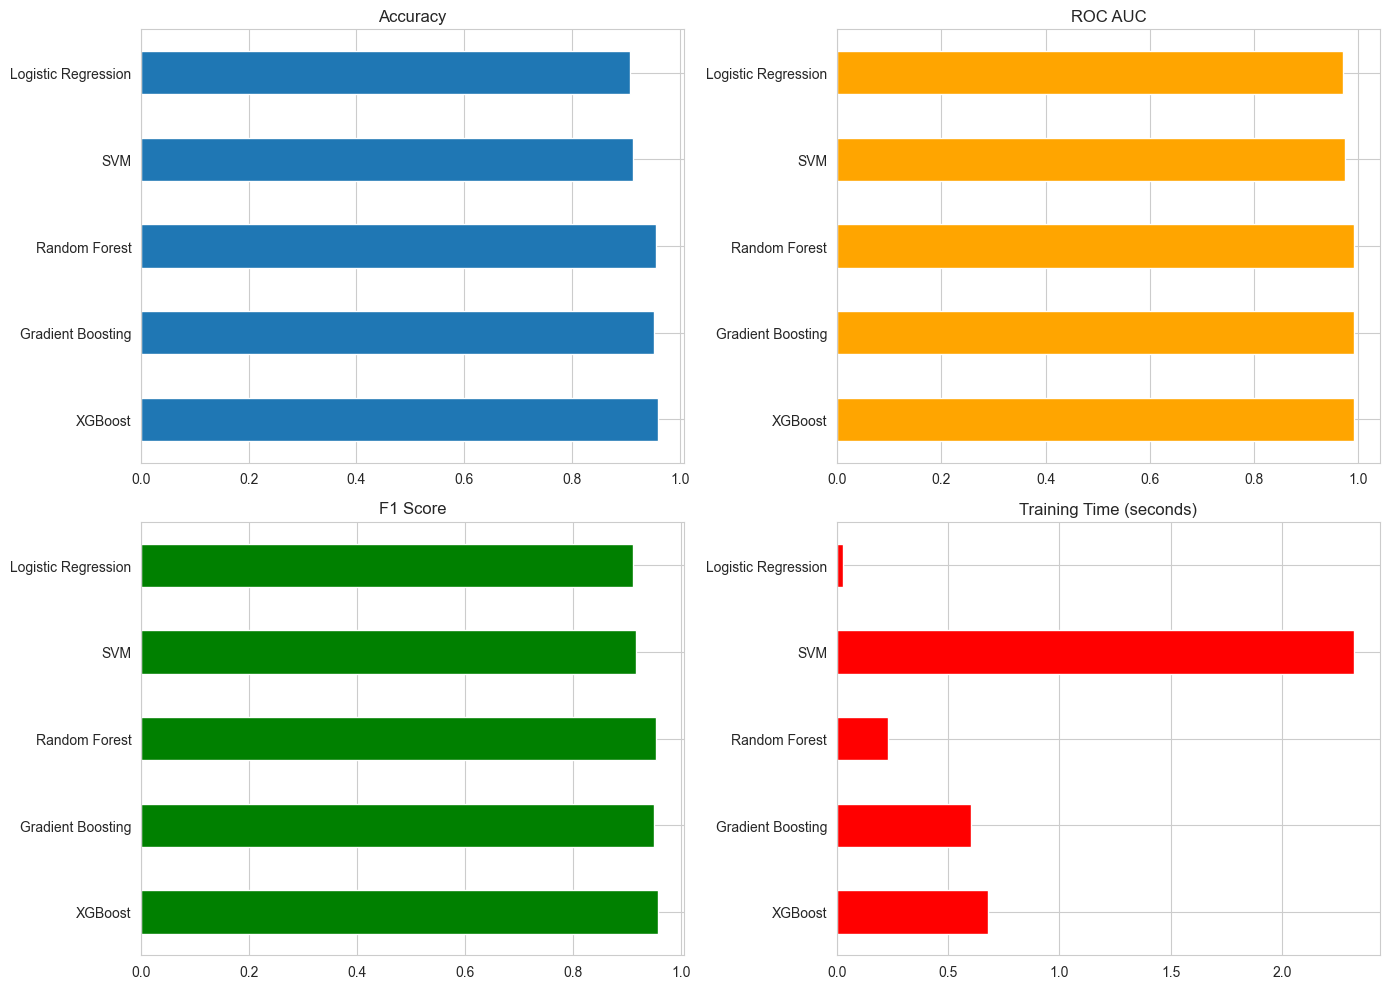

In [6]:
results_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

print("\nModel Comparison:")
print(results_df.to_string())

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

results_df[['accuracy']].plot(kind='barh', ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Accuracy')

results_df[['roc_auc']].plot(kind='barh', ax=axes[0, 1], legend=False, color='orange')
axes[0, 1].set_title('ROC AUC')

results_df[['f1']].plot(kind='barh', ax=axes[1, 0], legend=False, color='green')
axes[1, 0].set_title('F1 Score')

results_df[['time']].plot(kind='barh', ax=axes[1, 1], legend=False, color='red')
axes[1, 1].set_title('Training Time (seconds)')

plt.tight_layout()
plt.show()

## 6. Best Model Evaluation


Best Model: XGBoost
ROC AUC: 0.9917

Confusion Matrix:
[[651   7]
 [ 44 581]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96       658
      Attack       0.99      0.93      0.96       625

    accuracy                           0.96      1283
   macro avg       0.96      0.96      0.96      1283
weighted avg       0.96      0.96      0.96      1283



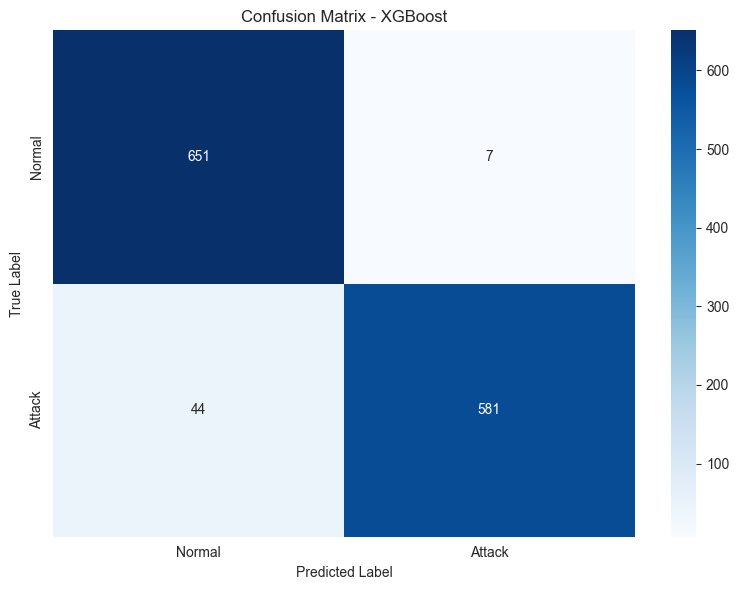

In [7]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"ROC AUC: {results_df.iloc[0]['roc_auc']:.4f}")

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 7. ROC Curve Analysis

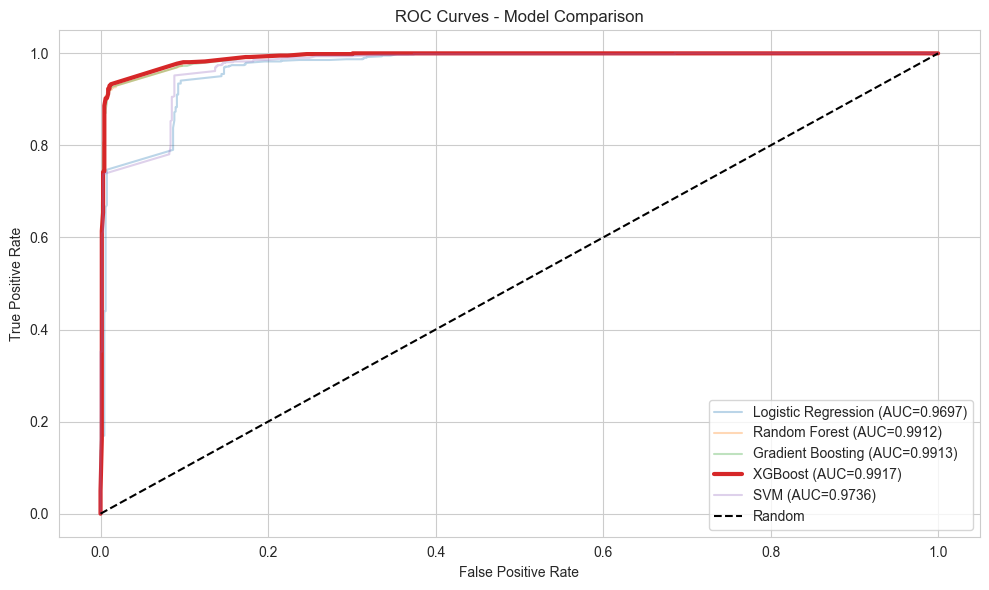

In [8]:
plt.figure(figsize=(10, 6))

for model_name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    
    if model_name == best_model_name:
        plt.plot(fpr, tpr, linewidth=3, label=f'{model_name} (AUC={auc_score:.4f})')
    else:
        plt.plot(fpr, tpr, alpha=0.3, label=f'{model_name} (AUC={auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Cross-Validation

In [9]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')

print(f"\n5-Fold Cross-Validation Results:")
print(f"Fold scores: {cv_scores}")
print(f"Mean AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


5-Fold Cross-Validation Results:
Fold scores: [0.99088973 0.98976806 0.98925475 0.98791825 0.98906476]
Mean AUC: 0.9894 (+/- 0.0019)


## 9. Feature Importance Analysis


Top 15 Important Features:
                 feature  importance
     query_special_chars    0.331308
body_special_chars_ratio    0.230266
          ip_attack_rate    0.135382
   request_freq_per_hour    0.091408
            header_count    0.043569
              path_depth    0.042177
         suspicious_path    0.036639
       query_param_count    0.024276
       user_agent_length    0.017523
                    hour    0.013811
        ip_request_count    0.013774
      path_encoded_chars    0.012808
             day_of_week    0.004400
       is_business_hours    0.001376
           is_night_time    0.001282


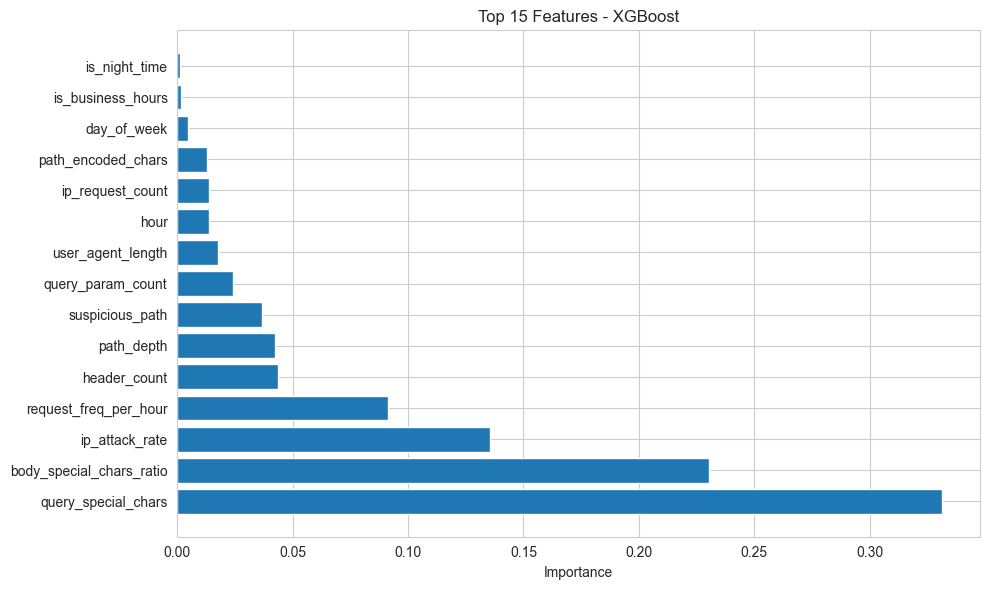

In [10]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 15 Important Features:")
    print(fi.head(15).to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(fi['feature'].head(15), fi['importance'].head(15))
    plt.xlabel('Importance')
    plt.title(f'Top 15 Features - {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance not available for {best_model_name}")

## 10. Save Best Model

In [11]:
# Save model
model_path = Path('../models/attack-detection-v0.1.1.pkl')
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"✓ Model saved to: {model_path}")

# Save model metadata
import json
metadata = {
    'model_name': best_model_name,
    'accuracy': float(results_df.iloc[0]['accuracy']),
    'roc_auc': float(results_df.iloc[0]['roc_auc']),
    'f1_score': float(results_df.iloc[0]['f1']),
    'precision': float(results_df.iloc[0]['precision']),
    'recall': float(results_df.iloc[0]['recall']),
    'num_features': X.shape[1]
}

metadata_path = Path('../models/model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved to: {metadata_path}")
print(f"\nModel Summary:")
for key, value in metadata.items():
    print(f"  {key}: {value}")

✓ Model saved to: ..\models\attack-detection-v0.1.1.pkl
✓ Metadata saved to: ..\models\model_metadata.json

Model Summary:
  model_name: XGBoost
  accuracy: 0.9602494154325799
  roc_auc: 0.9917434650455926
  f1_score: 0.9579554822753503
  precision: 0.9880952380952381
  recall: 0.9296
  num_features: 20
